  # <center><h4 style = "font-size: 50px; color:#3F37C9;">"Hidden Gems EDA" + W&B Integration</h4></center>
### <center>If you find this notebook useful, support with an upvote👍</center>

# <h4 style = "font-size: 40px; color:#3F37C9;">Table of Contents</h4>
<a id="toc"></a>
- [1. Introduction](#1)
- [2. Imports](#2)
- [3. Datasets](#3)
- [4. Data Cleaning](#4)
- [5. Gold Medalists](#5)
- [6. Top 30 Voted Authors + Performance Tiers](#6)
- [7. Top 30 Tags](#7)
- [8. WORD Clouds](#8)
    - [8.1 WORDCLOUD for Author Name](#8.1)
    - [8.2 WORDCLOUD for Title](#8.2)
    - [8.3 WORDCLOUD for Review](#8.3)
    - [8.4 WORDCLOUD for Tags](#8.4)
- [10. Text Preprocessing](#10)
- [11. Building word2Vec model](#11)
- [12. T-SNE](#12)
- [13. K-MEAN Clustering](#13)


# <center><h4 style = "font-size: 40px; color:#3F37C9;">Introduction</h4></center> 
<a id="1"></a>

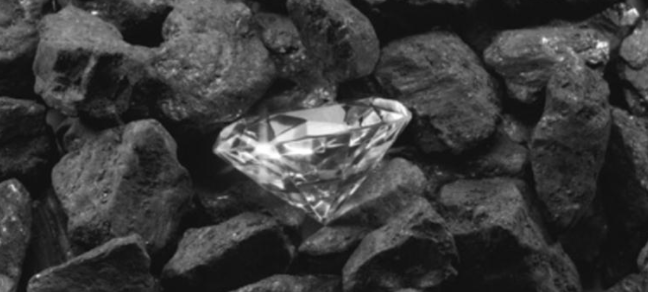

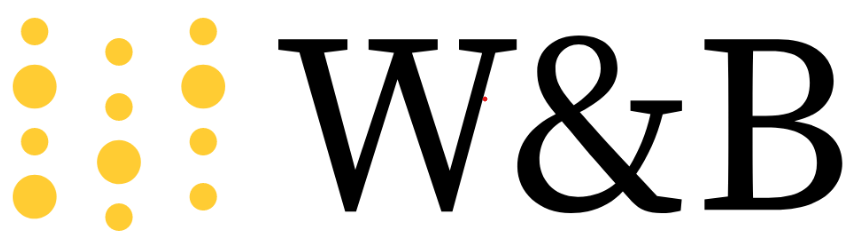


> [Notebooks of the Week - Hidden Gems](https://wandb.ai/tanya_/Hidden%20Gems?workspace=user-tanya_)💎💎
> 
> - Follow below steps to use W&B


Weight&Biases [project](https://wandb.ai/tanya_/Hidden%20Gems?workspace=user-tanya_)

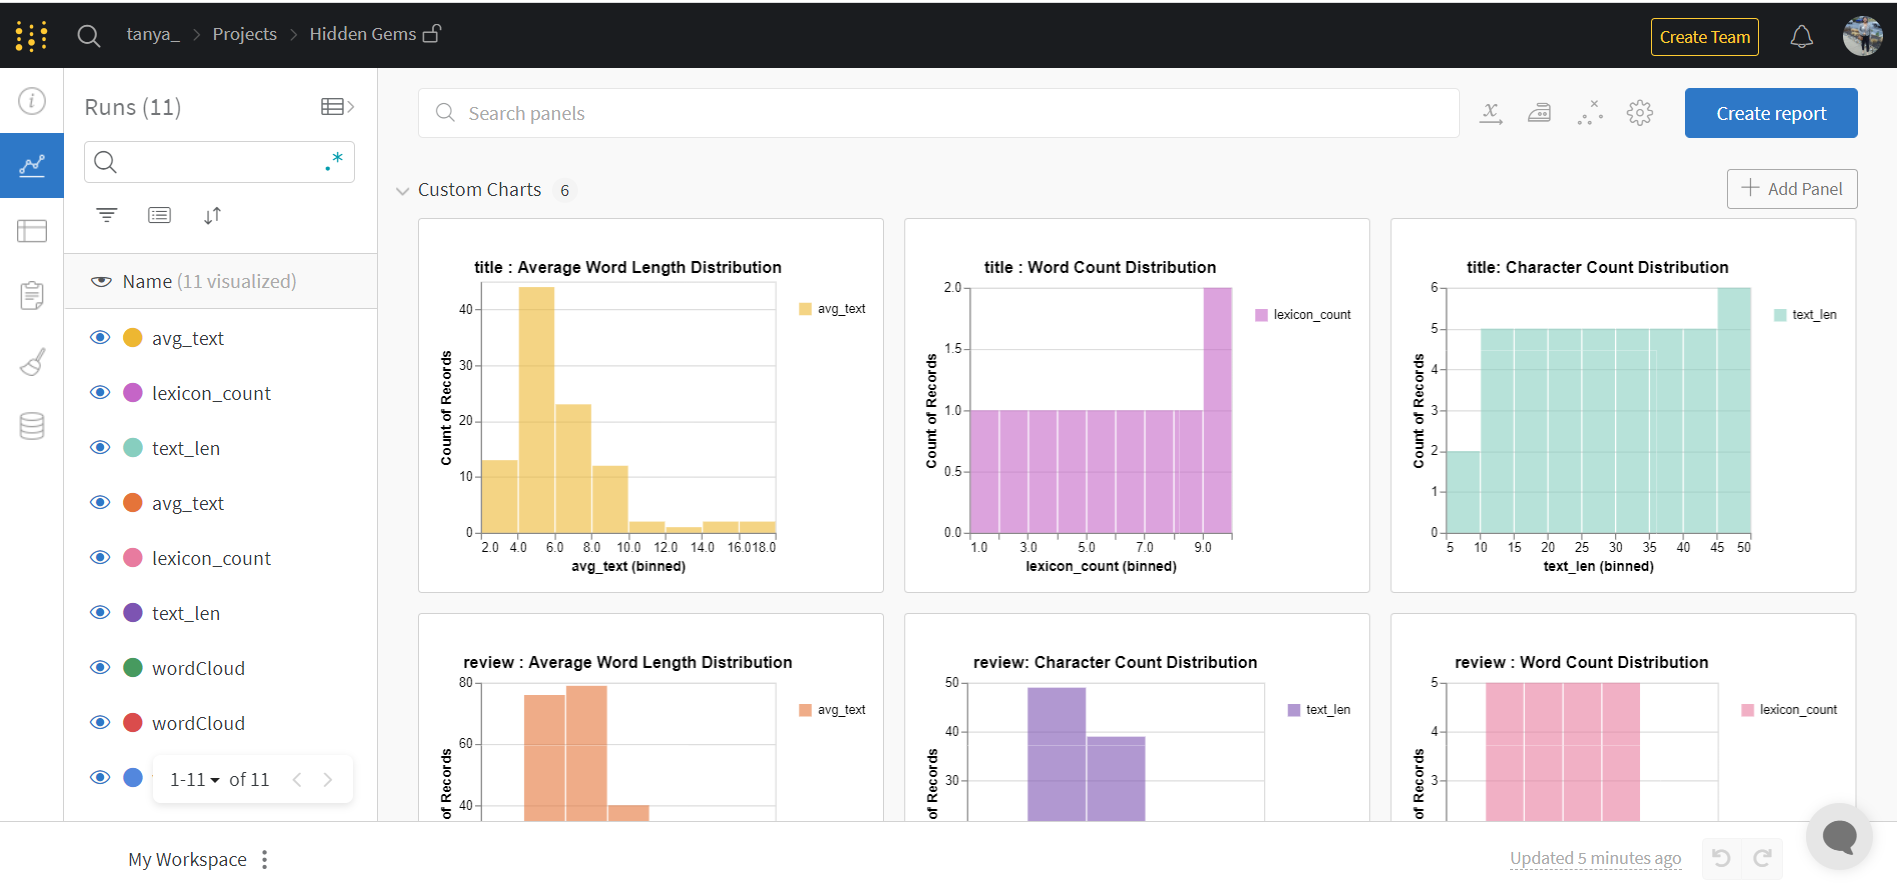

### Import wandb and log in¶

#### You will need a unique API key to log in to Weights & Biases.

 1.If you don't have a Weights & Biases account, you can go to https://wandb.ai/site and create a FREE account.           
 2.Access your API key: https://wandb.ai/authorize.

#### There are two ways you can login using a Kaggle kernel:

 1.Run a cell with wandb.login(). It will ask for the API key, which you can copy + paste in.                             
 2.You can also use Kaggle secrets 🤫 to store your API key and use the code snippet below to login. 


<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Imports</h4></center> 
<a id="2"></a>

In [1]:
!pip install textstat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import textstat

#wordcloud 
from wordcloud import WordCloud 

#W&B
#!pip install --upgrade -q wandb
import wandb
import os

#plotly
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go

%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns


import nltk
import regex as re
import string

#nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

# #gensim
from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

     |████████████████████████████████| 105 kB 528 kB/s            
     |████████████████████████████████| 2.0 MB 2.4 MB/s            


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("wandb_api")

#wandb.login(key=wandb_api)
! wandb login $wandb_api

os.environ["WANDB_SILENT"] = "true"

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Datasets</h4></center> 
<a id="3"></a>

In [3]:
kernels = pd.read_csv('/kaggle/input/meta-kaggle/Kernels.csv')
kernel_lang = pd.read_csv('/kaggle/input/meta-kaggle/KernelLanguages.csv')
kernel_tags = pd.read_csv('/kaggle/input/meta-kaggle/KernelTags.csv')
kernel_votes = pd.read_csv('/kaggle/input/meta-kaggle/KernelVotes.csv')
kernel_versions = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersions.csv')
kernel_competitions = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionCompetitionSources.csv')
kernel_users = pd.read_csv('/kaggle/input/meta-kaggle/Users.csv')
datasets = pd.read_csv('/kaggle/input/meta-kaggle/Datasets.csv')
kernel_datasets = pd.read_csv('/kaggle/input/meta-kaggle/KernelVersionDatasetSources.csv')
dataset_versions = pd.read_csv('/kaggle/input/meta-kaggle/DatasetVersions.csv')
tags = pd.read_csv('/kaggle/input/meta-kaggle/Tags.csv')
competitions = pd.read_csv('/kaggle/input/meta-kaggle/Competitions.csv')
messages = pd.read_csv('/kaggle/input/meta-kaggle/ForumMessages.csv')

In [4]:
hg_df = pd.read_csv("/kaggle/input/notebooks-of-the-week-hidden-gems/kaggle_hidden_gems.csv")
hg_df.head()

,vol,date,link_forum,link_twitter,notebook,author_kaggle,title,review,author_name,author_twitter,author_linkedin,notes
0,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,https://twitter.com/hansjoerg_me,NaN,NaN
1,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,https://twitter.com/pandeyparul,https://www.linkedin.com/in/parul-pandey-a5498...,NaN
2,1,2020-05-12,https://www.kaggle.com/general/150603,https://twitter.com/heads0rtai1s/status/126028...,https://www.kaggle.com/jonathanbouchet/u-s-com...,jonathanbouchet,U.S. Commercial Flights Tracker Map,Stunning maps are accompanied by lots of other...,Jonathan Bouchet,NaN,https://www.linkedin.com/in/jonathanbouchet,NaN
3,2,2020-05-19,https://www.kaggle.com/general/152383,https://twitter.com/heads0rtai1s/status/126279...,https://www.kaggle.com/andradaolteanu/unbiased...,andradaolteanu,Unbiased Look on Brazil Wildfires,A well-focused analysis on a globally importan...,Andrada Olteanu,https://twitter.com/andradaolteanuu,https://www.linkedin.com/in/andrada-olteanu-38...,NaN
4,2,2020-05-19,https://www.kaggle.com/general/152383,https://twitter.com/heads0rtai1s/status/126279...,https://www.kaggle.com/tunguz/mnist-2d-t-sne-w...,tunguz,MNIST 2D t-SNE with Rapids,One of the first Notebooks on Kaggle demonstra...,Bojan Tunguz,https://twitter.com/tunguz,https://www.linkedin.com/in/tunguz,NaN


**Column Description of kaggle_hidden_gems.csv:**
* `vol and date:` - The consecutive number of the Hidden Gems episode and when it was first published.
* `link_forum and link_twitter:` The hyperlinks to the Kaggle Forum post and Twitter post for the episode.
* `notebook and author:` The hyperlinks to the Notebook itself, as well as to the Kaggle profile of the author.
* `title:` The Notebook title as a string.
* `review:` My brief review of the Notebook.
* `author_name:` The name of the Notebook author as listed on their Kaggle profile at the time the episode was published.
* `author_twitter and author_linkedin` - The social media links of the author, if listed on their Kaggle profile.
* `notes` - Notes about special episodes.

In [5]:
#no of NaNs
round(hg_df.isnull().sum() * 100 / len(hg_df), 2)

vol                 0.00
date                0.00
link_forum          0.00
link_twitter        0.00
notebook            0.00
author_kaggle       0.00
title               0.00
review              0.00
author_name         0.00
author_twitter     64.00
author_linkedin    30.33
notes              93.00
dtype: float64

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;"> Data Cleaning</h4></center> 
<a id="4"></a>

In [6]:
#seperation the useful data
hg_df=hg_df[["date","notebook","author_kaggle","title","review","author_name"]]
hg_df.head()

,date,notebook,author_kaggle,title,review,author_name
0,2020-05-12,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey
2,2020-05-12,https://www.kaggle.com/jonathanbouchet/u-s-com...,jonathanbouchet,U.S. Commercial Flights Tracker Map,Stunning maps are accompanied by lots of other...,Jonathan Bouchet
3,2020-05-19,https://www.kaggle.com/andradaolteanu/unbiased...,andradaolteanu,Unbiased Look on Brazil Wildfires,A well-focused analysis on a globally importan...,Andrada Olteanu
4,2020-05-19,https://www.kaggle.com/tunguz/mnist-2d-t-sne-w...,tunguz,MNIST 2D t-SNE with Rapids,One of the first Notebooks on Kaggle demonstra...,Bojan Tunguz


In [7]:
# define a function to clean the review.
def clean_notebook(notebook):
    '''
    text: String
           Input Data
    text: String
           Output Data
           
    func: Convert text to lower case


    '''
    notebook = notebook.lower()
    notebook = re.search(r'([^/]+$)',notebook)

    return notebook.group() 

In [8]:
# clean the notebook and create a column
hg_df["clean_notebook"]=hg_df["notebook"].apply(lambda x:clean_notebook(x))
hg_df.head()

,date,notebook,author_kaggle,title,review,author_name,clean_notebook
0,2020-05-12,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,glmnet-xgboost-and-svm-using-tidymodels
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,breathe-india-covid-19-effect-on-pollution
2,2020-05-12,https://www.kaggle.com/jonathanbouchet/u-s-com...,jonathanbouchet,U.S. Commercial Flights Tracker Map,Stunning maps are accompanied by lots of other...,Jonathan Bouchet,u-s-commercial-flights-tracker-map
3,2020-05-19,https://www.kaggle.com/andradaolteanu/unbiased...,andradaolteanu,Unbiased Look on Brazil Wildfires,A well-focused analysis on a globally importan...,Andrada Olteanu,unbiased-look-on-brazil-wildfires
4,2020-05-19,https://www.kaggle.com/tunguz/mnist-2d-t-sne-w...,tunguz,MNIST 2D t-SNE with Rapids,One of the first Notebooks on Kaggle demonstra...,Bojan Tunguz,mnist-2d-t-sne-with-rapids


In [9]:
hg_df_kernel_merge = hg_df.join(kernels.set_index('CurrentUrlSlug')[["Id",'AuthorUserId','TotalVotes','Medal','TotalComments','TotalViews']], on='clean_notebook')
hg_df_kernel_merge.head()

,date,notebook,author_kaggle,title,review,author_name,clean_notebook,Id,AuthorUserId,TotalVotes,Medal,TotalComments,TotalViews
0,2020-05-12,https://www.kaggle.com/hansjoerg/glmnet-xgboos...,hansjoerg,"Glmnet, XGBoost, and SVM Using tidymodels",A well-structured and documented tutorial on h...,Hansjoerg,glmnet-xgboost-and-svm-using-tidymodels,7543648.0,4208588.0,41.0,2.0,7.0,12828.0
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,breathe-india-covid-19-effect-on-pollution,9228208.0,391404.0,219.0,1.0,38.0,26222.0
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,breathe-india-covid-19-effect-on-pollution,10597173.0,3565333.0,0.0,NaN,0.0,281.0
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,breathe-india-covid-19-effect-on-pollution,17005116.0,7428276.0,0.0,NaN,0.0,43.0
1,2020-05-12,https://www.kaggle.com/parulpandey/breathe-ind...,parulpandey,Breathe India: COVID-19 effect on Pollution,A detailed work studying the interaction betwe...,Parul Pandey,breathe-india-covid-19-effect-on-pollution,22212169.0,3520978.0,0.0,NaN,0.0,40.0


In [10]:
hg_df_kernel_user_merge = hg_df_kernel_merge.join(kernel_users.set_index('Id')[['UserName','DisplayName','PerformanceTier']], on='AuthorUserId')
#hg_df_kernel_user_merge

In [11]:
hg_df_kernel_user_merge = hg_df_kernel_user_merge.loc[(hg_df_kernel_user_merge['author_kaggle'] == hg_df_kernel_user_merge['UserName'])]
#hg_df_kernel_user_merge
                                  

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Gold Medalists</h4></center> 
<a id="5"></a>

In [12]:
hg_df_kernel_user_merge['Medal'].value_counts()
gold = len(hg_df_kernel_user_merge[ hg_df_kernel_user_merge['Medal'] == 1])
silver = len(hg_df_kernel_user_merge[ hg_df_kernel_user_merge['Medal'] == 2])
bronze = len(hg_df_kernel_user_merge[ hg_df_kernel_user_merge['Medal'] == 3])

<Figure size 1152x576 with 0 Axes>

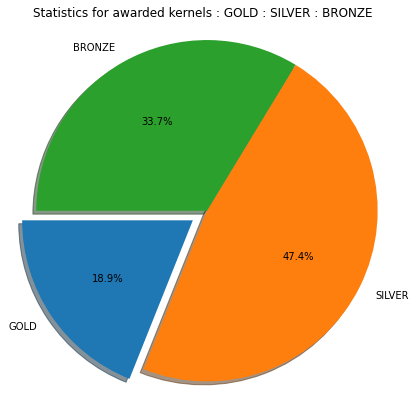

In [13]:
#plot statistics with matplotlib

run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='pieChart')

fig = plt.gcf()
fig.set_size_inches(16, 8)
labels = 'GOLD', 'SILVER', 'BRONZE'
sizes = [gold, silver, bronze]
explode = (0.1, 0, 0)  # only "explode" the 2nd slice (i.e. 'Hogs')

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=180)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

fig1.set_figheight(7)
fig1.set_figwidth(7)

plt.title('Statistics for awarded kernels : GOLD : SILVER : BRONZE')
fig = plt.axis('off')

wc_name =  "PieChart " + "Medals"
wandb.log({wc_name: [wandb.Image(plt, caption="pieChart")]})
run.finish()

In [14]:
def PerformanceTiers():
    df = pd.DataFrame([
        [0, 'Novice', '#5ac995'],
        [1, 'Contributor', '#00BBFF'],
        [2, 'Expert', '#95628f'],
        [3, 'Master', '#f96517'],
        [4, 'GrandMaster', '#dca917'],
        [5, 'KaggleTeam', '#008abb'],
    ], columns=['PerformanceTier', 'PerformanceTierName', 'PerformanceTierColor'])
    return df
    
tiers = PerformanceTiers()
tiers

,PerformanceTier,PerformanceTierName,PerformanceTierColor
0,0,Novice,#5ac995
1,1,Contributor,#00BBFF
2,2,Expert,#95628f
3,3,Master,#f96517
4,4,GrandMaster,#dca917
5,5,KaggleTeam,#008abb


In [15]:
hg_df_kernel_user_PerformanceTier_merge = hg_df_kernel_user_merge.join(tiers.set_index('PerformanceTier')[['PerformanceTierColor','PerformanceTierName']], on='PerformanceTier')
#hg_df_kernel_user_PerformanceTier_merge
votes_top_kernels = hg_df_kernel_user_PerformanceTier_merge.sort_values(by='TotalVotes', ascending=False)
votes_top_kernels.head()

,date,notebook,author_kaggle,title,review,author_name,clean_notebook,Id,AuthorUserId,TotalVotes,Medal,TotalComments,TotalViews,UserName,DisplayName,PerformanceTier,PerformanceTierColor,PerformanceTierName
66,2020-10-13,https://www.kaggle.com/rohanrao/tutorial-on-re...,rohanrao,Tutorial on reading large datasets,An impressively clean and accessible primer on...,Vopani,tutorial-on-reading-large-datasets,12234125.0,113389.0,1252.0,1.0,104.0,65432.0,rohanrao,Vopani,4.0,#dca917,GrandMaster
154,2021-05-04,https://www.kaggle.com/jessemostipak/dive-into...,jessemostipak,Dive into dplyr (tutorial #1),A well-structured guide to R dplyr functionali...,Jesse Mostipak,dive-into-dplyr-tutorial-1,12224820.0,4476084.0,966.0,1.0,84.0,210578.0,jessemostipak,Jesse Mostipak,2.0,#95628f,Expert
67,2020-10-13,https://www.kaggle.com/anasofiauzsoy/writing-h...,anasofiauzsoy,Writing Hamilton Lyrics with Tensorflow/R,History has its eyes on this R Keras tutorial ...,Ana Sofia Uzsoy,writing-hamilton-lyrics-with-tensorflow-r,10594470.0,5077172.0,328.0,1.0,23.0,33148.0,anasofiauzsoy,Ana Sofia Uzsoy,2.0,#95628f,Expert
40,2020-08-11,https://www.kaggle.com/yclaudel/recommendation...,yclaudel,Recommendation engine with networkx,Step-by-step guide to building a Netflix recom...,Yann Claudel,recommendation-engine-with-networkx,7957477.0,813707.0,252.0,1.0,14.0,21039.0,yclaudel,Yann Claudel,2.0,#95628f,Expert
229,2021-10-26,https://www.kaggle.com/tanlikesmath/petfinder-...,tanlikesmath,Petfinder Pawpularity EDA & fastai starter,A clean and concise FastAI starting point for ...,ilovescience,petfinder-pawpularity-eda-fastai-starter,21485799.0,674553.0,251.0,1.0,33.0,10597.0,tanlikesmath,ilovescience,3.0,#f96517,Master


<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Top 30 Voted Authors + Performance Tiers</h4></center> 
<a id="6"></a>
### <center><font color='#5ac995'>Novice, <font color='#00BBFF'>Contributor, <font color='#95628f'>Expert, <font color='#f96517'>Master, <font color='#dca917'>Grandmaster</font></center> 

#### Performance Tiers
Within each category of expertise, there are five performance tiers that can be achieved in accordance with the quality and quantity of work you produce. The colour of the band repesents the tier of the kaggler



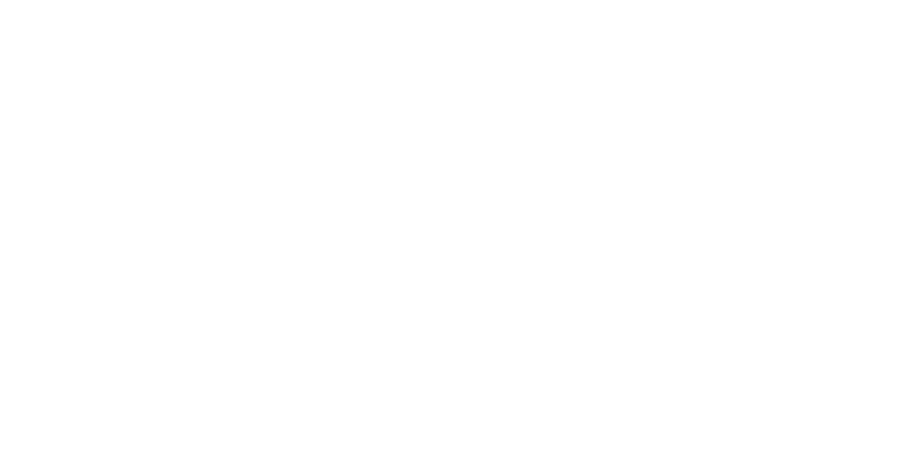

In [16]:
top_k_kernels = votes_top_kernels[:30]

run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='Top 30')

fig = plt.gcf()
fig.set_size_inches(16, 8)
data = [
    go.Bar(x=top_k_kernels['TotalVotes'].values,
           y=top_k_kernels['author_name'].values,
           marker=dict(color=top_k_kernels['PerformanceTierColor']),
           name= 'GrandMaster',
           orientation='h'
           )
    
]
layout = go.Layout(
    barmode='stack',
    height=500,
    title='Votes by voter tier',
    xaxis=dict(title='Votes', ticklen=5, zeroline=False, gridwidth=2),
    yaxis=dict(title='Author',showgrid=False, zeroline=False, showline=False, showticklabels=False),
    showlegend=True
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='VoterTierVotes')

#fig = plt.imshow(fig)
fig = plt.axis('off')
wc_name =  "Top 30 Voted Authors & Performance Tiers"
wandb.log({wc_name: [wandb.Image(plt, caption="Top 30")]})
run.finish()

# 

In [17]:
#tag_merge = pd.merge(kernel_tags, tags, on="ID", how="inner")
tag_merge = kernel_tags.join(tags.set_index('Id')[['Name']], on='TagId')
tag_merge.head()

,Id,KernelId,TagId,Name
0,3,239212,8317,housing
1,13,230838,13208,data visualization
2,37,351887,13207,computer vision
3,38,351887,13103,intermediate
4,70,340187,13304,clustering


In [18]:
#merging kernal with their tags Names
hg_df_kernel_user_tag_merge = hg_df_kernel_user_merge.join(tag_merge.set_index('KernelId')[['Name']], on='Id')
hg_df_kernel_user_tag_merge = hg_df_kernel_user_tag_merge[hg_df_kernel_user_tag_merge['Name'].notna()]
#hg_df_kernel_user_tag_merge.head()


In [19]:
top30_tags = hg_df_kernel_user_tag_merge['Name'].value_counts().head(30)
top30_tags = pd.DataFrame({'Tags':top30_tags.index, 'Count':top30_tags.values})
top30_tags

,Tags,Count
0,data visualization,112
1,exploratory data analysis,86
2,beginner,58
3,pandas,40
4,numpy,30
5,matplotlib,29
6,seaborn,28
7,gpu,25
8,plotly,25
9,deep learning,19


<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Top 30 Tags</h4></center> 
<a id="7"></a>

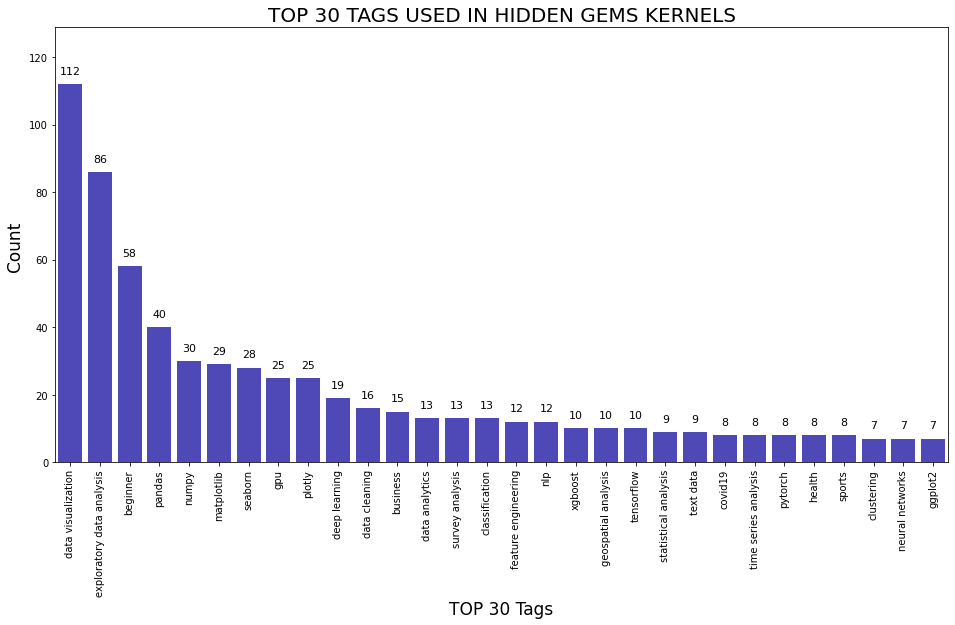

In [20]:
run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='BarGraph')

fig = plt.gcf()
fig.set_size_inches(16, 8)

#plt.figure(figsize=(14,6))
g2 = sns.barplot(x="Tags", y='Count',  
                 data=top30_tags,  color='#3F37C9')

g2.set_title("TOP 30 TAGS USED IN HIDDEN GEMS KERNELS", fontsize=20)
g2.set_ylabel("Count ",fontsize= 17)
g2.set_xlabel("TOP 30 Tags", fontsize=17)
sizes=[]
for p in g2.patches:
    height = p.get_height()
    sizes.append(height)
    g2.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.0f}'.format(height),
            ha="center", fontsize=11)
g2.set_ylim(0, max(sizes) * 1.15)
g2.set_xticklabels(g2.get_xticklabels(),
                  rotation=90)
#gt = g2.twinx()
plt.show()

wc_name =  "TOP 30 Tags Bar Graph "
wandb.log({wc_name: [wandb.Image(g2, caption="BarGraph")]})
run.finish()

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

# <center><h4 style = "font-size: 40px; color:#3F37C9;">Wordclouds</h4></center> 
<a id="8"></a>

In [21]:

def hiddenGems_wordcloud(column ,text):

    run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='wordcloud')
    
    fig = plt.gcf()
    fig.set_size_inches(18, 9)
    words=' '.join([words for words in text])
    wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(words)
    fig = plt.imshow(wordcloud, interpolation="bilinear")
    fig = plt.axis('off')
    
    wc_name =  "WordCloud for" + column
    wandb.log({wc_name: [wandb.Image(plt, caption="Wordcloud")]})
    run.finish()



## <h4 style = "font-size: 30px; color:#3F37C9;">WORDCLOUD for Author Name</h4>
<a id="8.1"></a>

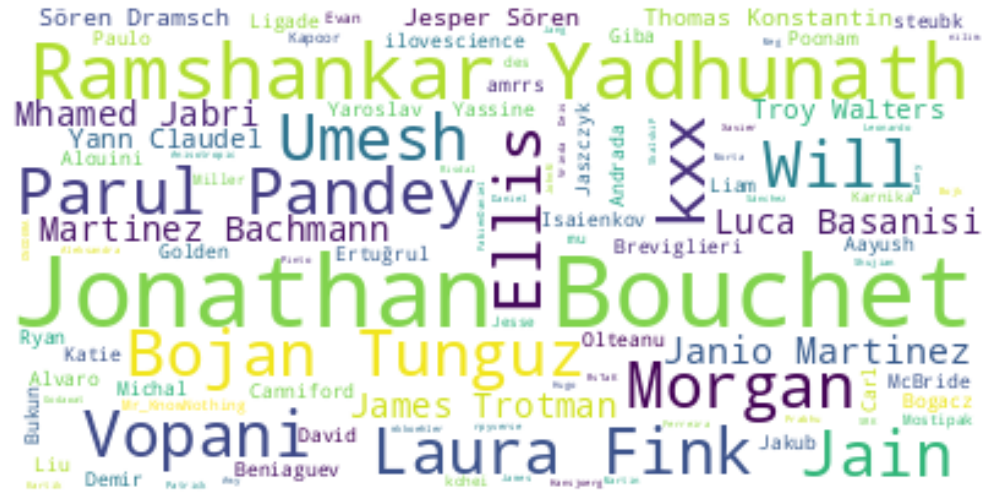

In [22]:
hiddenGems_wordcloud("Author Name",hg_df["author_name"].values)

## <h4 style = "font-size: 30px; color:#3F37C9;">WORDCLOUD for Title</h4>
<a id="8.2"></a>

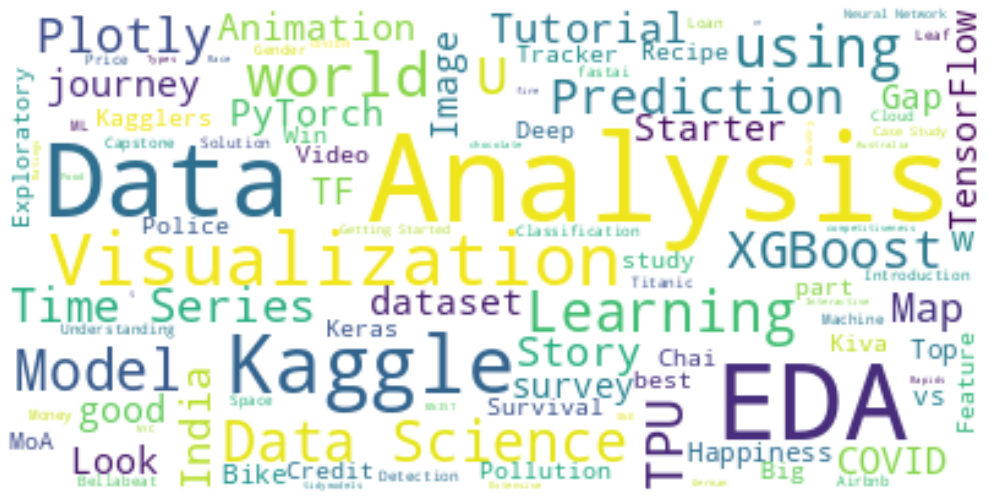

In [23]:
hiddenGems_wordcloud("Title",hg_df["title"].values)

## <h4 style = "font-size: 30px; color:#3F37C9;">WORDCLOUD for Review</h4>
<a id="8.3"></a>

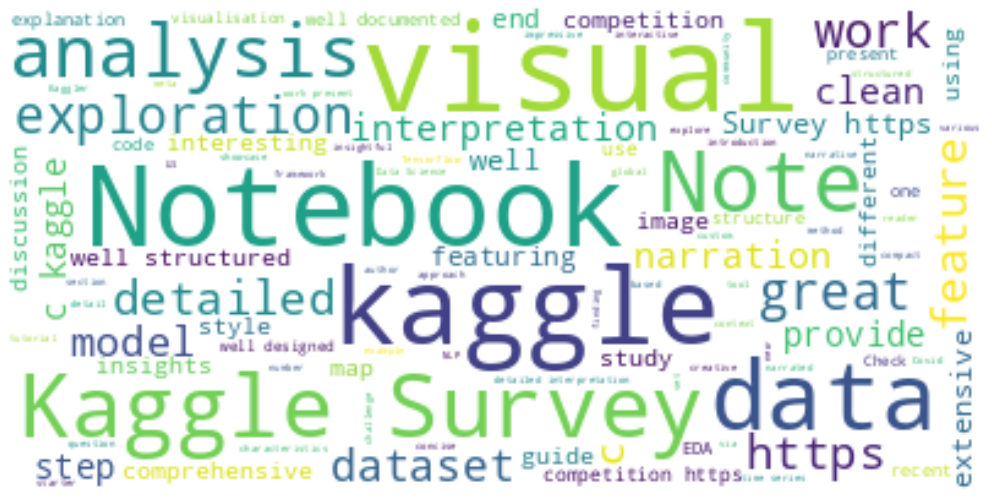

In [24]:
hiddenGems_wordcloud("Review",hg_df["review"].values)

## <h4 style = "font-size: 30px; color:#3F37C9;">WORDCLOUD for Tags</h4>
<a id="8.4"></a>

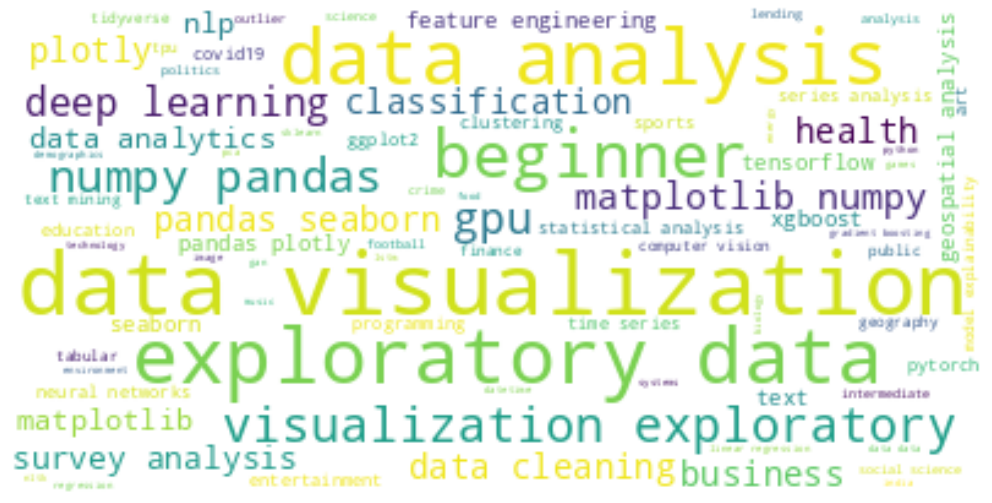

In [25]:
hiddenGems_wordcloud("Tags",hg_df_kernel_user_tag_merge["Name"].values)

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>


# <center><h4 style = "font-size: 40px; color:#3F37C9;">Text Preprocessing</h4></center> 
<a id="10"></a>

In [26]:
def text_preprocessing(data):
    data = str(data).lower()
    data = re.sub('\[.*?\]', '', data)
    data = re.sub('https?:\/\/[a-zA-Z@:%._\/+~#=?&;]*', '', data)
    data = re.sub('[^a-zA-Z0-9\-\']', ' ', data)
    data = re.sub('<.*?>+', '', data)
    data = re.sub('\n', '', data)
    return data

In [27]:
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in STOPWORDS])

In [28]:
hg_df["review"] = hg_df["review"].apply(lambda text: text_preprocessing(text))
hg_df["review"]  = hg_df["review"] .apply(lambda text: remove_stopwords(text))


In [29]:
hg_df['tr_word_count']= hg_df["review"].apply(lambda x: len(str(x).split(' ')))


In [30]:
documents = []

for doc in hg_df["review"]:
    documents.append(doc.split(' '))

In [31]:
#Converting the clean text in the format supported by embeddings.
sent = [row for row in documents]
#use Gensim Phrases package to automatically detect common phrases (bigrams) from a list of sentences.
phrases = Phrases(sent, min_count=1, progress_per=50000)
bigram = Phraser(phrases)
sentences = bigram[sent]
sentences[4]

['one',
 'first',
 'notebooks',
 'kaggle',
 'demonstrating',
 'game-changing',
 'speed',
 'provided',
 "nvidia's",
 'gpu-magic',
 'tools',
 'exhibit',
 'concise',
 'powerful',
 'code']

array([[<AxesSubplot:title={'center':'tr_word_count'}>]], dtype=object)

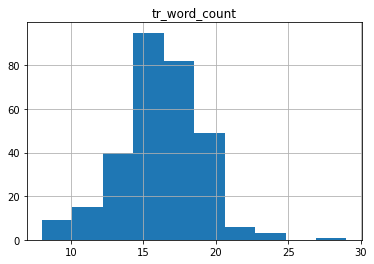

In [32]:
hg_df.hist(column = 'tr_word_count') #most of the transcription are in range of 20 words

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>


# <center><h4 style = "font-size: 40px; color:#3F37C9;">Building word2Vec model</h4></center> 
<a id="11"></a>

In [33]:
#Initializing the word2vec model

import multiprocessing

w2v_model = Word2Vec(min_count=4,
                     window=5,
                     vector_size=100,
                     sample=1e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20,
                     seed= 42,
                     workers=multiprocessing.cpu_count()-1)


#building vocab of the word2vec model from the custom data
w2v_model.build_vocab(sentences, progress_per=50000)

In [34]:
#training the word2vec model
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

(3253, 128700)

In [35]:
#How many words in the model and how many features
w2v_model.wv.vectors.shape

(269, 100)

In [36]:
#saving the word2vec model
w2v_model.save("word2vec_Medical Specialty Clustering")

In [37]:
#Loading the word2vec model
word_vectors = Word2Vec.load("word2vec_Medical Specialty Clustering").wv

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>


# <center><h4 style = "font-size: 40px; color:#3F37C9;">T-SNE</h4></center> 
<a id="12"></a>

Using t-SNE we can reduce our high dimensional features vector to 2 dimensions. By using the 2 dimensions as x,y coordinates, the body_text can be plotted. t-SNE will attempt to preserve the relations of the higher dimensional data as closely as possible when shrunk to 2D. The similar article will thus be in closer proximity to each other.

In [38]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, verbose=1, perplexity=10, n_iter=1000,init='pca',random_state=42)  # Changed perplexity from 100 to 50 per FAQ
X_embedded = tsne.fit_transform(word_vectors.vectors.astype('double'))


/opt/conda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.

/opt/conda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning:

The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.



[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 269 samples in 0.000s...
[t-SNE] Computed neighbors for 269 samples in 0.015s...
[t-SNE] Computed conditional probabilities for sample 269 / 269
[t-SNE] Mean sigma: 0.014367
[t-SNE] KL divergence after 250 iterations with early exaggeration: 90.859444
[t-SNE] KL divergence after 1000 iterations: 1.984796


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



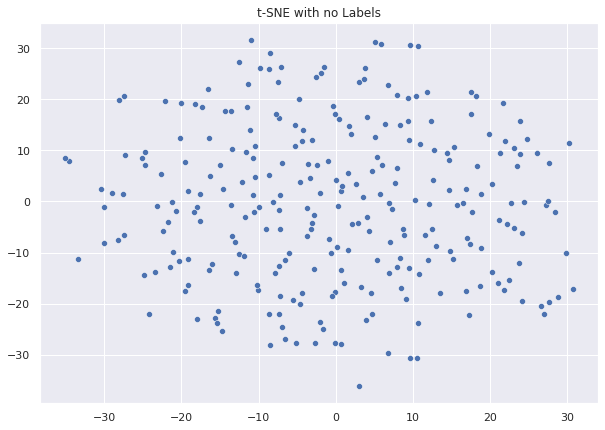

In [39]:
#how data looks like when compressed into 2 dimensions

from matplotlib import pyplot as plt
import seaborn as sns

# sns settings
sns.set(rc={'figure.figsize':(10,7)})

# colors
palette = sns.color_palette("bright", 1)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], palette=palette)
plt.title('t-SNE with no Labels')
plt.savefig("t-sne_HiddenGem.png")
plt.show()

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>



# <center><h4 style = "font-size: 40px; color:#3F37C9;">K-MEAN Clustering</h4></center> 
<a id="13"></a>

In [40]:
#Feeding the embeddings to a KMeans model to cluster words into multiple clusters
from sklearn.cluster import KMeans

kmeans_models = [KMeans(n_clusters=k,init='k-means++',max_iter=1000, random_state=42, n_init=10).fit(X=X_embedded) for k in range (1, 25)]
innertia = [model.inertia_ for model in kmeans_models]
print(innertia)


[124911.40625, 79552.984375, 50655.8828125, 37133.1484375, 30300.822265625, 24345.67578125, 20450.47265625, 17579.4296875, 15616.2861328125, 14514.7392578125, 12980.4716796875, 11921.8486328125, 10974.5673828125, 10210.369140625, 9415.845703125, 8929.609375, 8051.75830078125, 7748.8525390625, 7265.35205078125, 6870.447265625, 6478.69580078125, 6034.5712890625, 5779.30615234375, 5517.5888671875]


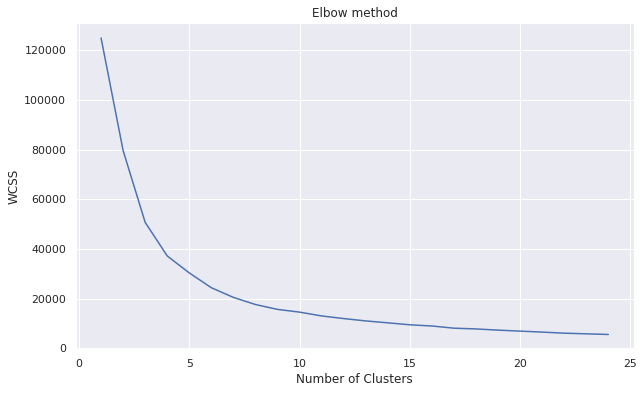

In [41]:
run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='Elbow_plot')

fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.rcParams["figure.figsize"] = (10,6)
plt.plot(range(1, 25), innertia)
plt.title('Elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

wc_name =  "Find Number of Clusters"
wandb.log({wc_name: [wandb.Image(fig, caption="linegraph")]})
run.finish()

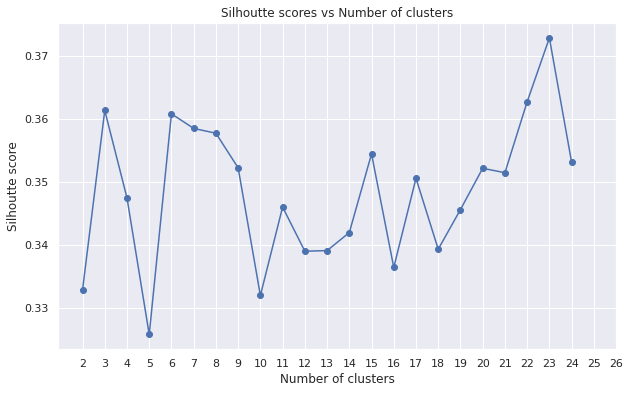

In [42]:
# We will use silhouette score to see which one performs better.
from sklearn.metrics import silhouette_score

run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='Silhoutte scores')

fig = plt.gcf()
fig.set_size_inches(10, 6)
silhoutte_scores = [silhouette_score(X_embedded, model.labels_) for model in kmeans_models[1:25]]
plt.plot(range(2,25), silhoutte_scores, "bo-")
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26])
plt.title('Silhoutte scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

wc_name =  "Silhoutte scores vs Number of clusters"
wandb.log({wc_name: [wandb.Image(fig, caption="linegraph")]})
run.finish()

In [43]:
#predict the labels of clusters.
for ele in kmeans_models[0:5]:
    label = ele.fit_predict(X_embedded)
    centroids = ele.cluster_centers_

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



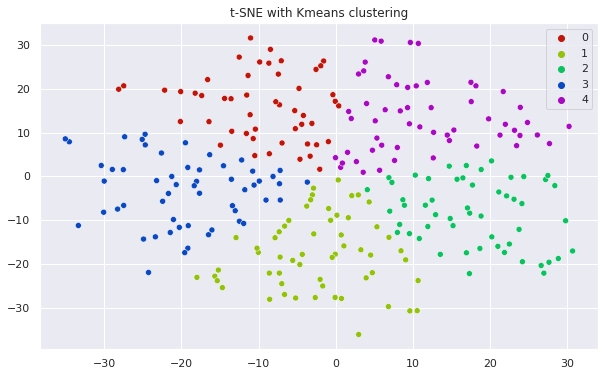

In [44]:
run = wandb.init(project='Hidden Gems', job_type='image-visualization',name='t-SNE with Kmeans clustering ')

fig = plt.gcf()
fig.set_size_inches(10, 6)

# sns settings
sns.set(rc={'figure.figsize':(10,6)})

# colors
palette = sns.hls_palette(5, l=.4, s=.9)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], hue=label, legend='full', palette=palette)
plt.title('t-SNE with Kmeans clustering')
plt.savefig("improved_cluster_tsne.png")
plt.show()

wc_name =  "t-SNE with Kmeans clustering "
wandb.log({wc_name: [wandb.Image(fig, caption="scatterplot")]})
run.finish()

<a href="#toc" role="button" aria-pressed="true" >⬆️Back to Table of Contents ⬆️</a>

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; color:#3F37C9;line-height: 1.7em;">
    
    
### <center>Thank you for reading🙂</center>
### <center>If you have any feedback or find anything wrong, please let me know!</center>

# [In Progress ....]